# 02 — Preprocessing
**Resume Classification — Deep Learning Project**

Notebook ini melakukan semua persiapan data sebelum tokenisasi dan training.

---
**Input  :** `data/raw/df_dataset_Resume_cleaned.csv`  
**Output :** `data/processed/train.pkl`, `val.pkl`, `test.pkl`, `label_encoder.pkl`

## 1. Setup & Import Library

In [1]:
import pandas as pd
import numpy as np
import re
import pickle
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Path
RAW_PATH       = '../data/raw/df_dataset_Resume_cleaned.csv'
PROCESSED_DIR  = '../data/processed/'

# Buat folder processed jika belum ada
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Seed untuk reproducibility
RANDOM_STATE = 42

print('Setup selesai!')

Setup selesai!


## 2. Load Data

In [2]:
df = pd.read_csv(RAW_PATH)

print(f'Data dimuat: {len(df):,} baris')
print(f'Kolom      : {df.columns.tolist()}')
print()
df.head(3)

Data dimuat: 6,844 baris
Kolom      : ['category', 'job_title', 'Text']



,category,job_title,Text
0,Java Developers/Architects Resumes,Java Developer,Flair for technology and willing to take chall...
1,Java Developers/Architects Resumes,Sr. Java/J2EE Developer,Senior Java Developer with around 7+ years of ...
2,Java Developers/Architects Resumes,Sr. iOS Developer,Overall 7 years of experience in design and de...


## 3. Hapus Duplikat

In [3]:
n_before = len(df)
n_dup    = df['Text'].duplicated().sum()

print(f'Baris sebelum  : {n_before:,}')
print(f'Duplikat teks  : {n_dup:,}')

# Hapus duplikat berdasarkan kolom Text
# keep='first' → simpan kemunculan pertama
df = df.drop_duplicates(subset='Text', keep='first').reset_index(drop=True)

print(f'Baris sesudah  : {len(df):,}')
print(f'Baris dihapus  : {n_before - len(df):,}')

Baris sebelum  : 6,844
Duplikat teks  : 1,103
Baris sesudah  : 5,741
Baris dihapus  : 1,103


In [4]:
# Cek distribusi kategori setelah deduplikasi
print('Distribusi kategori setelah deduplikasi:')
print(df['category'].value_counts())

# Pastikan tidak ada kelas yang hilang
print(f'\nJumlah kelas: {df["category"].nunique()}')

Distribusi kategori setelah deduplikasi:
category
Datawarehousing, ETL, Informatica Resumes         881
SQL Developers Resumes                            747
Business Intelligence, Business Object Resumes    708
Web Developer Resumes                             706
Network and Systems Administrators Resumes        674
Project Manager Resumes                           661
Business Analyst (BA) Resumes                     584
Java Developers/Architects Resumes                447
Recruiter Resumes                                 333
Name: count, dtype: int64

Jumlah kelas: 9


## 4. Cleaning Teks

In [ ]:
def clean_text(text: str) -> str:
    """
    Membersihkan teks resume dari noise.
    Catatan: tidak melakukan stemming/lemmatization karena
    BERT/Longformer sudah punya subword tokenizer sendiri.
    """
    # Hapus URL
    text = re.sub(r'http\S+|www\.\S+', ' ', text)

    # Hapus email
    text = re.sub(r'\S+@\S+', ' ', text)

    # Hapus karakter non-ASCII
    text = text.encode('ascii', errors='ignore').decode()

    # Ganti punctuation dengan spasi (kecuali apostrof)
    text = re.sub(r"[^a-zA-Z0-9'\s]", ' ', text)

    # Hapus angka yang berdiri sendiri
    text = re.sub(r'\b\d+\b', ' ', text)

    # Normalisasi spasi
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Preview sebelum & sesudah
sample_raw   = df['Text'].iloc[0]
sample_clean = clean_text(sample_raw)

print('=== SEBELUM CLEANING ===')
print(sample_raw[:300])
print()
print('=== SESUDAH CLEANING ===')
print(sample_clean[:300])

=== SEBELUM CLEANING ===
Flair for technology and willing to take challenging assignments with over 6 years of versatile experience in analysis, design, development and implementation of N - tier architecture based applications, Business to Business Applications, Business to Client based applications, distributed components

=== SESUDAH CLEANING ===
Flair for technology and willing to take challenging assignments with over years of versatile experience in analysis design development and implementation of N tier architecture based applications Business to Business Applications Business to Client based applications distributed components internet


In [6]:
# Terapkan ke seluruh dataset
df['clean_text'] = df['Text'].apply(clean_text)

# Verifikasi tidak ada teks kosong setelah cleaning
n_empty = (df['clean_text'].str.strip() == '').sum()
print(f'Teks kosong setelah cleaning: {n_empty}')

# Bandingkan jumlah kata sebelum & sesudah
df['wc_before'] = df['Text'].str.split().str.len()
df['wc_after']  = df['clean_text'].str.split().str.len()

print(f'\nRata-rata kata SEBELUM : {df["wc_before"].mean():.0f}')
print(f'Rata-rata kata SESUDAH : {df["wc_after"].mean():.0f}')

# Hapus kolom bantu
df = df.drop(columns=['wc_before', 'wc_after'])

Teks kosong setelah cleaning: 0

Rata-rata kata SEBELUM : 1553
Rata-rata kata SESUDAH : 1558


## 5. Label Encoding

In [7]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['category'])

# Simpan LabelEncoder untuk dipakai saat inference nanti
le_path = os.path.join(PROCESSED_DIR, 'label_encoder.pkl')
with open(le_path, 'wb') as f:
    pickle.dump(le, f)

print('Label mapping:')
for idx, cls in enumerate(le.classes_):
    count = (df['label'] == idx).sum()
    print(f'  {idx} -> {cls:55s} ({count} sampel)')

print(f'\nLabelEncoder disimpan ke: {le_path}')

Label mapping:
  0 -> Business Analyst (BA) Resumes                           (584 sampel)
  1 -> Business Intelligence, Business Object Resumes          (708 sampel)
  2 -> Datawarehousing, ETL, Informatica Resumes               (881 sampel)
  3 -> Java Developers/Architects Resumes                      (447 sampel)
  4 -> Network and Systems Administrators Resumes              (674 sampel)
  5 -> Project Manager Resumes                                 (661 sampel)
  6 -> Recruiter Resumes                                       (333 sampel)
  7 -> SQL Developers Resumes                                  (747 sampel)
  8 -> Web Developer Resumes                                   (706 sampel)

LabelEncoder disimpan ke: ../data/processed/label_encoder.pkl


## 6. Train / Validation / Test Split

In [8]:
# Split 70% train | 15% val | 15% test
# stratify=label memastikan proporsi kelas sama di ketiga split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=df['label']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temp_df['label']
)

# Reset index
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train : {len(train_df):,} baris ({len(train_df)/len(df)*100:.1f}%)')
print(f'Val   : {len(val_df):,} baris ({len(val_df)/len(df)*100:.1f}%)')
print(f'Test  : {len(test_df):,} baris ({len(test_df)/len(df)*100:.1f}%)')

Train : 4,018 baris (70.0%)
Val   : 861 baris (15.0%)
Test  : 862 baris (15.0%)


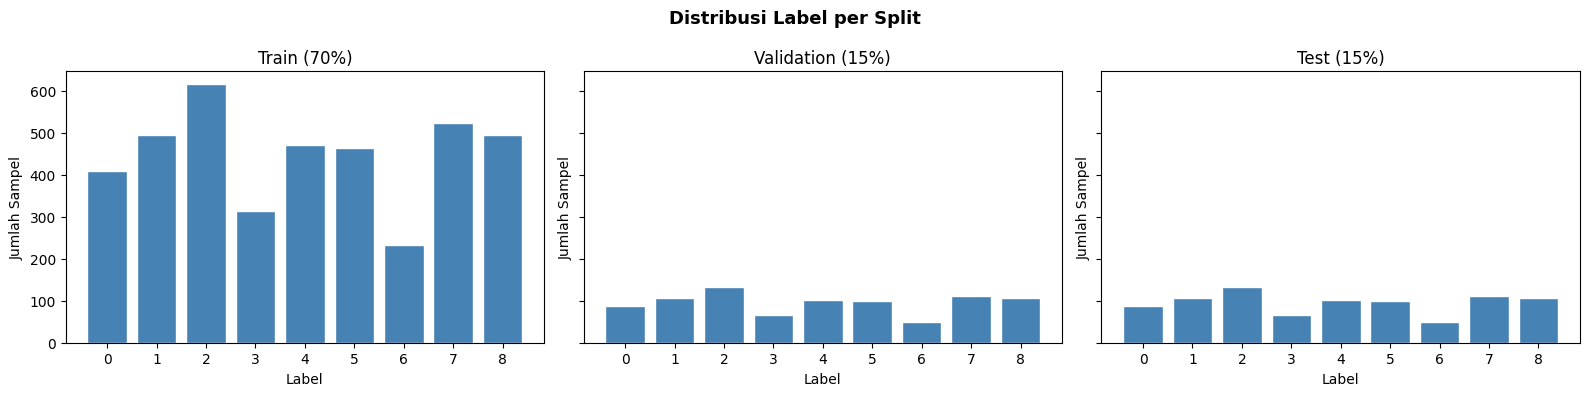


Distribusi tiap split:
  Train: [409 495 616 313 472 463 233 523 494]
  Val: [ 88 106 132  67 101  99  50 112 106]
  Test: [ 87 107 133  67 101  99  50 112 106]


In [9]:
# Verifikasi distribusi label tiap split (harus proporsional)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, split_df, title in zip(
    axes,
    [train_df, val_df, test_df],
    ['Train (70%)', 'Validation (15%)', 'Test (15%)']
):
    counts = split_df['label'].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Label')
    ax.set_ylabel('Jumlah Sampel')
    ax.set_xticks(range(len(le.classes_)))

plt.suptitle('Distribusi Label per Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/preprocessing_split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nDistribusi tiap split:')
for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    dist = split['label'].value_counts().sort_index().values
    print(f'  {name}: {dist}')

## 7. Pilih Kolom yang Dibutuhkan & Simpan

In [11]:
# Kolom yang dibutuhkan untuk notebook selanjutnya
KEEP_COLS = ['clean_text', 'label', 'category']

train_df = train_df[KEEP_COLS]
val_df   = val_df[KEEP_COLS]
test_df  = test_df[KEEP_COLS]

print('Kolom yang disimpan:', KEEP_COLS)
print()
print('Contoh baris train:')
train_df.head(5)

Kolom yang disimpan: ['clean_text', 'label', 'category']

Contoh baris train:


,clean_text,label,category
0,Over years of IT experience in Various RDBMS D...,8,Web Developer Resumes
1,More than years of experience in Information T...,8,Web Developer Resumes
2,Having around years of experience in IT indust...,8,Web Developer Resumes
3,Around years of experience in Web Development ...,6,Recruiter Resumes
4,Proven experience in high level fast paced env...,2,"Datawarehousing, ETL, Informatica Resumes"


In [12]:
# Simpan ke pickle (lebih cepat dibaca dibanding CSV untuk data besar)
train_df.to_pickle(os.path.join(PROCESSED_DIR, 'train.pkl'))
val_df.to_pickle(os.path.join(PROCESSED_DIR, 'val.pkl'))
test_df.to_pickle(os.path.join(PROCESSED_DIR, 'test.pkl'))

print('File berhasil disimpan:')
for fname in ['train.pkl', 'val.pkl', 'test.pkl', 'label_encoder.pkl']:
    fpath = os.path.join(PROCESSED_DIR, fname)
    size  = os.path.getsize(fpath) / 1024
    print(f'  {fpath}  ({size:.1f} KB)')

File berhasil disimpan:
  ../data/processed/train.pkl  (42328.8 KB)
  ../data/processed/val.pkl  (9546.8 KB)
  ../data/processed/test.pkl  (9105.7 KB)
  ../data/processed/label_encoder.pkl  (0.5 KB)


## 8. Verifikasi Output

In [13]:
# Load ulang untuk memastikan file bisa dibaca dengan benar
train_check = pd.read_pickle(os.path.join(PROCESSED_DIR, 'train.pkl'))
val_check   = pd.read_pickle(os.path.join(PROCESSED_DIR, 'val.pkl'))
test_check  = pd.read_pickle(os.path.join(PROCESSED_DIR, 'test.pkl'))

with open(os.path.join(PROCESSED_DIR, 'label_encoder.pkl'), 'rb') as f:
    le_check = pickle.load(f)

print('Verifikasi berhasil!')
print(f'  Train shape : {train_check.shape}')
print(f'  Val shape   : {val_check.shape}')
print(f'  Test shape  : {test_check.shape}')
print(f'  Kelas label : {le_check.classes_.tolist()}')
print()

# Cek satu sampel
sample = train_check.iloc[0]
print('Contoh satu baris dari train:')
print(f'  label    : {sample["label"]} -> {le_check.classes_[sample["label"]]}')
print(f'  teks     : {sample["clean_text"][:150]}...')

Verifikasi berhasil!
  Train shape : (4018, 3)
  Val shape   : (861, 3)
  Test shape  : (862, 3)
  Kelas label : ['Business Analyst (BA) Resumes', 'Business Intelligence, Business Object Resumes', 'Datawarehousing, ETL, Informatica Resumes', 'Java Developers/Architects Resumes', 'Network and Systems Administrators Resumes', 'Project Manager Resumes', 'Recruiter Resumes', 'SQL Developers Resumes', 'Web Developer Resumes']

Contoh satu baris dari train:
  label    : 8 -> Web Developer Resumes
  teks     : Over years of IT experience in Various RDBMS Data warehousing ETL OLAP Tools and Client Server applications years of Hands on experience in Data wareh...


## 9. Ringkasan

In [15]:
print('=' * 60)
print('RINGKASAN PREPROCESSING')
print('=' * 60)
print(f"""
LANGKAH YANG DILAKUKAN
  1. Hapus duplikat  : {n_dup} baris dihapus (sisa {len(df):,})
  2. Cleaning teks   : hapus URL, email, punctuation, angka
  3. Label encoding  : 9 kelas -> integer 0-8
  4. Split data      : 70% train / 15% val / 15% test (stratified)

OUTPUT
  data/processed/train.pkl          ({len(train_df):,} baris)
  data/processed/val.pkl            ({len(val_df):,} baris)
  data/processed/test.pkl           ({len(test_df):,} baris)
  data/processed/label_encoder.pkl  (9 kelas)

CATATAN UNTUK NOTEBOOK BERIKUTNYA
  - Kolom yang dipakai   : 'clean_text' dan 'label'
  - Teks masih panjang   : rata-rata ~1.585 kata
  - Pilih max_length     : 512 (BERT) atau 4096 (Longformer)
""")
print('=' * 60)

RINGKASAN PREPROCESSING

LANGKAH YANG DILAKUKAN
  1. Hapus duplikat  : 1103 baris dihapus (sisa 5,741)
  2. Cleaning teks   : hapus URL, email, punctuation, angka
  3. Label encoding  : 9 kelas -> integer 0-8
  4. Split data      : 70% train / 15% val / 15% test (stratified)

OUTPUT
  data/processed/train.pkl          (4,018 baris)
  data/processed/val.pkl            (861 baris)
  data/processed/test.pkl           (862 baris)
  data/processed/label_encoder.pkl  (9 kelas)

CATATAN UNTUK NOTEBOOK BERIKUTNYA
  - Kolom yang dipakai   : 'clean_text' dan 'label'
  - Teks masih panjang   : rata-rata ~1.585 kata
  - Pilih max_length     : 512 (BERT) atau 4096 (Longformer)

